In [61]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot
from freealg.visualization._api_plot_util import _decimal_text, _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'dmp'
save_filename = 'ntk_cifar_resnet50_fp64_n64K'
latex = True

# NTK CIFAR-10 ResNet50

In [62]:
config1 = dict(
    input_filename = 'ntk_cifar_resnet50_fp64_n64K_eigs.npz',
    # input_filename = 'ntk_cifar_resnet9_fp64_n64K_eigs.npz',
    deg_m = 3,
    effective_n = 80_000,
    xlim = (0, 0.8),
    ylim = [(0, 19), (0, 19), (0, 7)],
    nbins = (80, 200),
    label_mode = 'pow-dec',
    save_filename = 'ntk_cifar10_resnet50_64K',
)

# -------

config = config1

Idx   Size   Repeat
---  -----   ------
0     1000       10
1     2000        5
2     4000        3
3     8000        2
4    16000        2
5    32000        1
6    64000        1



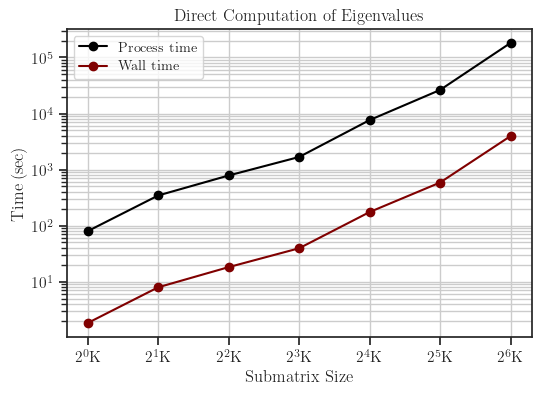

In [63]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
# repeats = out['repeats']
eigs_repeated = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']
# proc_name = out['proc_name']
# num_proc = out['num_proc']
# date = out['date']

# concatenate all repeats
repeats = numpy.zeros((len(eigs),), dtype=int)
max_repeat = 3
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    repeats[i] = eigs_repeated[i].shape[0]
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()
    # s = eigs_repeated[i].shape[0]
    # shift = min(s-1, 2)
    # eigs[i] = eigs_repeated[i][shift:shift+rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
# print(f'proc name: {proc_name}')
# print(f'num proc:  {num_proc}')
# print(f'date:      {date}')
# print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

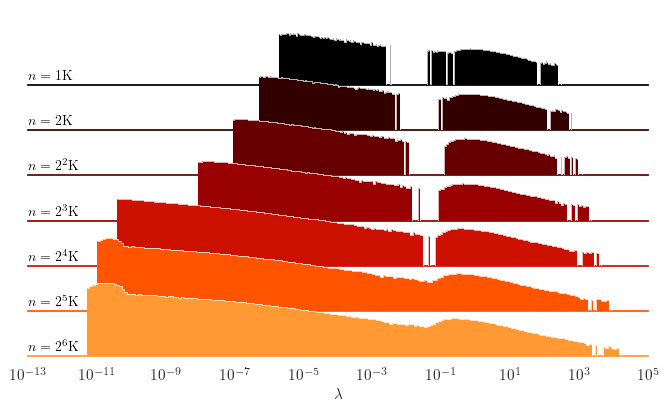

In [54]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(1e-13, 1e5), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

# Fit Spectral Curve


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0000,    0.0114)
	Interval 2: (   0.1210,  232.1217)
	Interval 3: ( 271.7132,  957.7885)
	Interval 4: (1121.1520, 1312.3793)

------------------------------------------
fit residual max  : 6.6989e+01
fit residual 99.9%: 2.6030e+01

Coefficients (real)
+0.06651459 -0.01441436 -0.00021165 -0.00000054 -0.00000000 -0.00000000 -0.00000000 -0.00000000 +0.00000000 
-0.93042753 +1.00710718 -0.25718823 -0.00239931 -0.00000634 -0.00000002 -0.00000000 -0.00000000 -0.00000000 
+0.00304710 -1.64425596 +0.36283559 -0.21838637 +0.00038588 -0.00000009 +0.00000000 -0.00000000 +0.00000000 
-0.00001076 +0.00332476 -0.70495813 +0.00023164 -0.00000047 +0.00000000 -0.00000000 +0.00000000 -0.00000000 
+0.00000002 -0.00001084 +0.00023773 -0.00000005 +0.00000000 -0.00000000 +0.00000000 -0.00000000 +0.00000000 
-0.00000000 +0.00000002 -0.00000001 +0.00000000 -0.00000000 +0.00000000 -0.00000000 +0.00000000 +0.000000

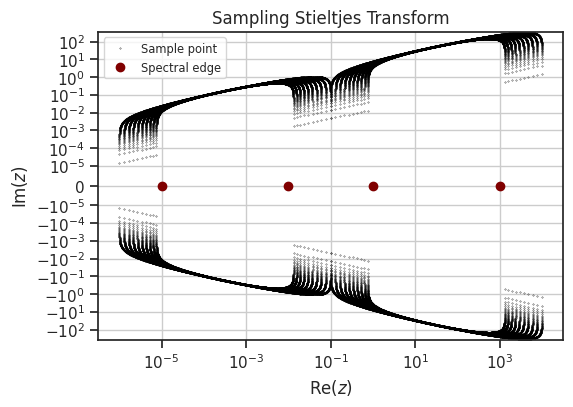

In [89]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 2

# Detect support from histogram
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# Stieltjes options (Homotopy)
stieltjes_opt = dict(
    n_levels = 500,
    max_subdivide = 20,
    anchor_mode = 'empirical',
    # anchor_mode = 'asymptotic',
    anchor_y_min = 1e-3,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 100,
    anchor_ratio = 1,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.05,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes (Plemelj)
inv_stieltjes_opt = dict(
    delta = 1e-5,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=[(1e-5, 1e-2), (1, 1000)],
                   # support=support,
                   # support=None,
                   n=sizes[start_idx],
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# 8, 4
# 7, 3
deg_m, deg_z = 8, 8

deg_mu = 1
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r_min=1.5, r_max=3, n_r=10,
    # y_scale=100.0, gamma=0.1,
    y_scale=1.0, gamma=0.5,
    n_samples=4096 // 2,
    cut_eps=0.01,
    normalize=True,
    triangular=None,
    # mu='auto',
    mu=None,
    mu_reg=None, verbose=True, plot=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')

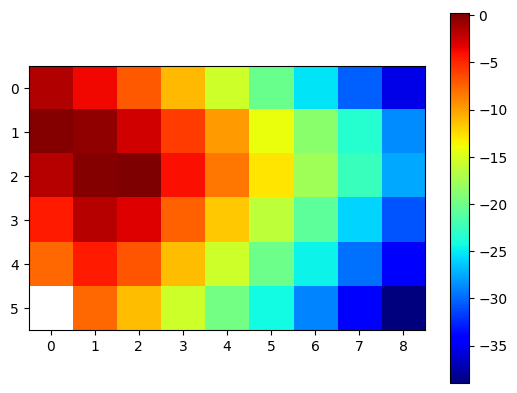

In [88]:
%matplotlib inline

p = plt.imshow(numpy.log10(numpy.abs(af.coeffs.real)), cmap=plt.cm.jet)
plt.colorbar(p)
plt.show()

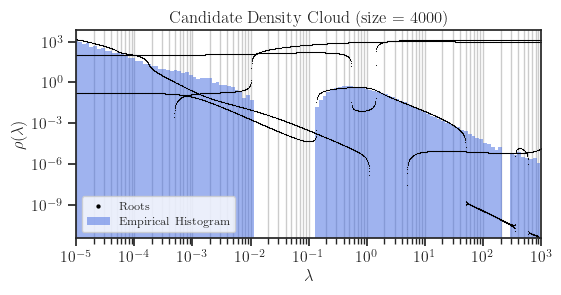

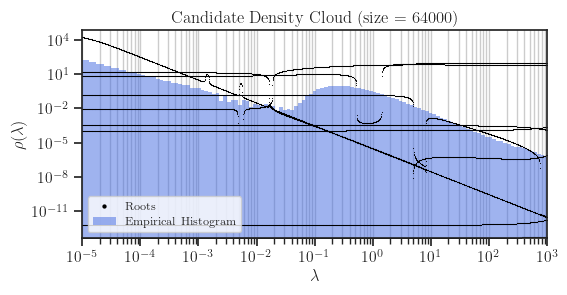

In [90]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 2000)

%matplotlib inline

# for idx in range(start_idx, sizes.size):
for idx in [start_idx, sizes.size-1]:
    af.candidates(
        size=sizes[idx],
        kind='free',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

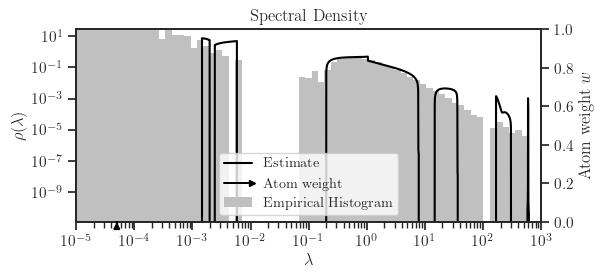


Mass: 1.01087449


In [8]:
# Plot density
x_min = 1e-6
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 5000)
rho0 = af.density(x, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x)
print(f'Mass: {mass:0.8f}')

# Free Decompression

In [ ]:
# Choosing the largest sub-matrix size to decompress to
# end_idx = sizes.size - 1
end_idx = 6

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-11
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 2000)

newton_opt = dict(
    dt_max=0.01,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=10,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)